# 3 — Voter ensemble, ou travailler ensemble

**Ce que ce notebook établit :** la cosignature d'amendements révèle des
alliances que le vote ne montre pas, et en dément d'autres. Trois résultats —
la gauche vote ensemble sans travailler ensemble (LFI↔ECOS : **88 %** d'accord
de vote, **0,1 %** des cosignatures) ; DR et UDDPLR votent ensemble à **74 %**
avec **zéro** amendement cosigné ; HOR est le seul groupe qui cosigne davantage
hors de ses rangs qu'en son sein.

**Le choix invisible de ce notebook : la relation mesurée.** Les notebooks `01`
et `02` ne regardent que les votes. Or le vote n'est qu'une des traces qu'un
député laisse, et pas la plus révélatrice.

Il établit aussi que trois artefacts méthodologiques suffisent à produire des
résultats entièrement faux mais parfaitement crédibles, et comment les
neutraliser. Suite du fil : `04` s'attaquera à la méthode elle-même.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from radar import analyze, cosign, viz
from radar.parse import load

viz.set_theme("clair")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(40)

polars.config.Config

## 1. L'hypothèse

Le vote et la cosignature ne mesurent pas la même chose.

**Voter** est contraint. Le groupe donne une consigne, la discipline est forte —
la cohésion intra-groupe dépasse 90 % partout (cf. notebook `01`). Un vote
conforme n'apprend donc pas grand-chose sur les affinités personnelles.

**Cosigner** est volontaire. Personne n'est tenu d'apposer son nom sur
l'amendement d'un collègue, et surtout personne ne le fait par inadvertance sur
celui d'un adversaire. C'est un acte public, traçable, et coûteux en capital
politique.

L'hypothèse : ces deux réseaux ne se superposent pas, et leurs écarts sont
informatifs.

## 2. La méthode

Un amendement signé par A (auteur) et cosigné par B et C crée les liens A–B,
A–C et B–C. On construit la matrice d'incidence creuse (députés × amendements)
et le produit `D · Dᵀ` donne, pour chaque paire, le nombre d'amendements
cosignés ensemble.

L'affinité est mesurée par l'indice de **Jaccard** — `communs / (total_A +
total_B − communs)` — et non par le compte brut, qui ne remonterait que les
députés les plus prolifiques.

In [2]:
amd = load("amendements")
print(f"amendements            : {amd.height:,}")
print(f"avec au moins un cosignataire : {amd.filter(pl.col('nb_cosignataires') > 0).height:,}")
print(f"liens de cosignature   : {amd['nb_cosignataires'].sum():,}")

amendements            : 123,224
avec au moins un cosignataire : 92,729
liens de cosignature   : 3,094,562


## 3. Premier piège : les dépôts de groupe entier

Trois millions de liens, c'est beaucoup pour 577 députés. Avant d'interpréter
quoi que ce soit, il faut regarder combien de signatures porte un amendement
typique.

In [3]:
n_sig = amd["nb_cosignataires"] + 1
for q in (0.5, 0.75, 0.90, 0.95):
    print(f"  quantile {q:.0%} : {int(n_sig.quantile(q)):3d} signataires")
print(f"  maximum     : {int(n_sig.max())}")
print()
print("effectifs des groupes :")
print(load("deputes").filter(pl.col("en_exercice"))
      .group_by("groupe").len().sort("len", descending=True).head(4))

  quantile 50% :  10 signataires
  quantile 75% :  37 signataires
  quantile 90% :  71 signataires
  quantile 95% :  71 signataires
  maximum     : 190

effectifs des groupes :
shape: (4, 2)
┌─────────┬─────┐
│ groupe  ┆ len │
│ ---     ┆ --- │
│ str     ┆ u32 │
╞═════════╪═════╡
│ RN      ┆ 122 │
│ EPR     ┆ 90  │
│ LFI-NFP ┆ 71  │
│ SOC     ┆ 68  │
└─────────┴─────┘


Le 90ᵉ centile est à 71 signataires — soit exactement l'effectif du groupe
LFI. Ce ne sont pas des affinités, ce sont des **dépôts collectifs** : le groupe
signe en bloc. Or un amendement à 71 signatures crée à lui seul 2 485 liens, et
relie mécaniquement tous les membres du groupe deux à deux.

Sans plafond, le réseau ne mesure donc pas l'affinité entre personnes mais
l'appartenance à un groupe — c'est-à-dire une information qu'on avait déjà.

Voyons à quel point le résultat dépend de ce plafond.

In [4]:
lignes = []
for seuil in (None, 100, 40, 20, 10, 6):
    r = cosign.build_reseau(max_signataires=seuil, exclure_rapporteurs=False)
    top = cosign.paires_cosignataires(r, k=1, min_signatures=10, min_communs=3)
    lignes.append({
        "plafond": seuil or 9999,
        "amendements_retenus": r.n_amendements,
        "signatures_medianes": int(np.median(r.signatures)),
        "paire_de_tete": f"{top['depute_a'][0]} ({top['groupe_a'][0]}) ↔ "
                         f"{top['depute_b'][0]} ({top['groupe_b'][0]})",
    })
pl.DataFrame(lignes)

plafond,amendements_retenus,signatures_medianes,paire_de_tete
i64,i64,i64,str
9999,92022,4433,"""Christine Le Nabour (HOR) ↔ Michel Lauzz…"
100,87947,1377,"""Christine Le Nabour (HOR) ↔ Michel Lauzz…"
40,64281,924,"""Gaëtan Dussausaye (RN) ↔ Sandra Delannoy…"
20,47052,423,"""Guillaume Florquin (RN) ↔ Sandra Delanno…"
10,32316,146,"""Christine Le Nabour (HOR) ↔ Michel Lauzz…"
6,20926,56,"""Brigitte Liso (EPR) ↔ Élise Leboucher (L…"


La paire de tête change complètement selon le plafond. Le seuil n'est donc pas
un détail de réglage : c'est une décision de méthode qu'il faut assumer et
documenter. Le radar retient **10 signataires** par défaut — au-delà, on
considère qu'il s'agit d'un dépôt collectif.

## 4. Second piège : les rapporteurs

À plafond bas, une paire spectaculaire apparaît : une députée EPR et une députée
LFI, deux blocs qui ne votent ensemble qu'un tiers du temps, avec une affinité
de cosignature de 0,79. Trop beau pour être vrai — vérifions de quoi sont faits
leurs amendements communs.

In [5]:
d = load("deputes").filter(pl.col("nom_complet").is_in(["Brigitte Liso", "Élise Leboucher"]))
uids = dict(zip(d["nom_complet"], d["acteur_uid"]))
signataires = pl.concat_list(pl.col("auteur_uid").fill_null(""), pl.col("cosignataires"))

communs = amd.filter(
    (pl.col("nb_cosignataires") + 1 <= 10)
    & signataires.list.contains(uids["Brigitte Liso"])
    & signataires.list.contains(uids["Élise Leboucher"])
)
print(f"amendements communs : {communs.height}")
print(communs["sort"].value_counts().sort("count", descending=True))
print()
for t in communs["expose_sommaire"].drop_nulls().head(4).to_list():
    print(" •", t[:90])

amendements communs : 94
shape: (5, 2)
┌────────┬───────┐
│ sort   ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ Adopté ┆ 86    │
│ Retiré ┆ 4     │
│ Tombé  ┆ 2     │
│ Rejeté ┆ 1     │
│ null   ┆ 1     │
└────────┴───────┘

 • Amendement de précision.
 • Amendement de précision rédactionnelle, qui supprime une répétition introduite en première
 • Amendement rédactionnel.
 • Amendement rédactionnel.


Des amendements **rédactionnels**, adoptés à plus de 90 %. Ces deux députées
sont co-rapporteures d'un même texte : elles corédigent des ajustements
techniques au nom de la commission. C'est un **rôle institutionnel**, pas une
alliance politique.

L'open data expose le champ qui permet de les repérer —
`auteurRapporteurOrganeRef`, non nul quand l'amendement est déposé au nom d'une
commission. Le radar le stocke sous `auteur_rapporteur` et l'écarte par défaut.

In [6]:
print(f"amendements de rapporteur : {amd['auteur_rapporteur'].sum():,} "
      f"({amd['auteur_rapporteur'].mean():.1%})")

amendements de rapporteur : 1,641 (1.3%)


## 5. Troisième piège : la taille des groupes

Pour trouver les « courtiers » — ceux qui travaillent hors de leur camp — le
réflexe est de calculer la part des cosignatures adressées à d'autres groupes.
C'est un piège : un membre d'un groupe de 17 a 96 % de l'Assemblée hors de son
groupe, contre 79 % pour un membre d'un groupe de 122. Classer sur la part brute
revient à classer les groupes par petitesse.

La première version de ce code faisait exactement cette erreur, et son palmarès
était intégralement occupé par le plus petit groupe.

**La correction :** rapporter la part observée à la part attendue sous mélange
aléatoire, `(N − effectif) / (N − 1)`. Un ratio de 1 signifie « cosigne hors de
son groupe exactement autant que le hasard le prédirait ».

In [7]:
reseau = cosign.build_reseau()          # plafond 10, rapporteurs exclus
print(f"amendements retenus : {reseau.n_amendements:,}")

cosign.courtiers(reseau, k=12).select(
    "nom_complet", "groupe", "signatures",
    "part_hors_groupe", "part_attendue", "ratio",
)

amendements retenus : 31,881


nom_complet,groupe,signatures,part_hors_groupe,part_attendue,ratio
str,str,i64,f64,f64,f64
"""Christine Le Nabour""","""HOR""",362,0.992879,0.939236,1.057113
"""Antoine Golliot""","""RN""",108,0.712919,0.789931,0.902508
"""Philippe Fait""","""HOR""",610,0.779788,0.939236,0.830237
"""Pierre Meurin""","""RN""",54,0.618881,0.789931,0.783463
"""Jimmy Pahun""","""DEM""",142,0.727869,0.9375,0.776393
"""Martine Froger""","""SOC""",480,0.68198,0.883681,0.77175
"""Sabine Thillaye""","""DEM""",97,0.683511,0.9375,0.729078
"""Jean-Michel Brard""","""HOR""",94,0.677419,0.939236,0.721245
"""Maud Petit""","""DEM""",252,0.647312,0.9375,0.690466


Résultat inattendu : **presque personne ne dépasse 1**. La cosignature est
massivement intra-groupe, bien plus que le hasard ne le voudrait, et le
« courtage » entre groupes est un phénomène marginal à l'Assemblée. Seule
Christine Le Nabour (HOR) dépasse le seuil — et la suite explique pourquoi.

C'est un résultat négatif, mais c'en est un : il n'existe pas, dans cette
législature, de figure individuelle qui fasse le lien entre les blocs par le
travail législatif.

## 6. Les résultats, au niveau des groupes

findfont: Failed to find font weight semibold, now using 700.


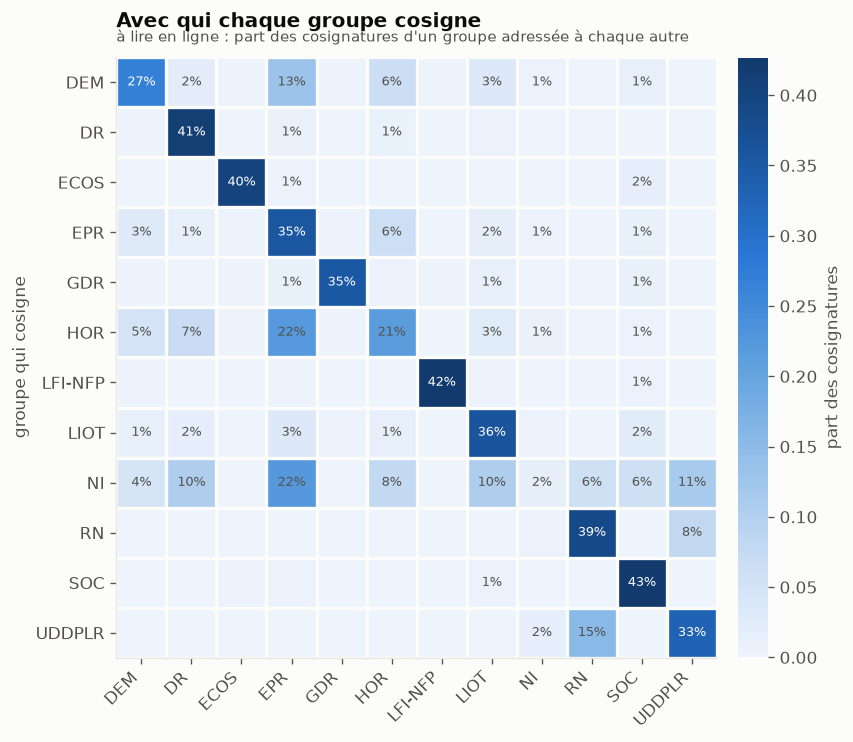

In [8]:
parts = cosign.cosignatures_entre_groupes(reseau)
viz.heatmap_cosignatures(parts)
plt.show()

In [9]:
# Pour chaque groupe, ses trois principales destinations de cosignature.
for grp in sorted(parts["groupe_a"].unique().to_list()):
    top = parts.filter(pl.col("groupe_a") == grp).sort("part", descending=True).head(3)
    dest = "   ".join(f"{r['groupe_b']} {r['part']:.0%}" for r in top.iter_rows(named=True))
    print(f"  {grp:8s} → {dest}")

  DEM      → DEM 27%   EPR 13%   HOR 6%
  DR       → DR 41%   HOR 1%   EPR 1%
  ECOS     → ECOS 40%   SOC 2%   EPR 1%
  EPR      → EPR 35%   HOR 6%   DEM 3%
  GDR      → GDR 35%   LIOT 1%   SOC 1%
  HOR      → EPR 22%   HOR 21%   DR 7%
  LFI-NFP  → LFI-NFP 42%   SOC 1%   EPR 0%
  LIOT     → LIOT 36%   EPR 3%   SOC 2%
  NI       → EPR 22%   UDDPLR 11%   DR 10%
  RN       → RN 39%   UDDPLR 8%   NI 0%
  SOC      → SOC 43%   LIOT 1%   EPR 0%
  UDDPLR   → UDDPLR 33%   RN 15%   NI 2%


**HOR est l'exception de l'Assemblée.** C'est le seul groupe dont la première
destination de cosignature n'est pas lui-même : il adresse plus de cosignatures
à EPR qu'à ses propres membres. Le groupe fonctionne en satellite du bloc
présidentiel — ce que les votes seuls ne révèlent pas, puisque HOR y garde une
cohésion interne de 90 %.

## 7. Là où vote et cosignature divergent

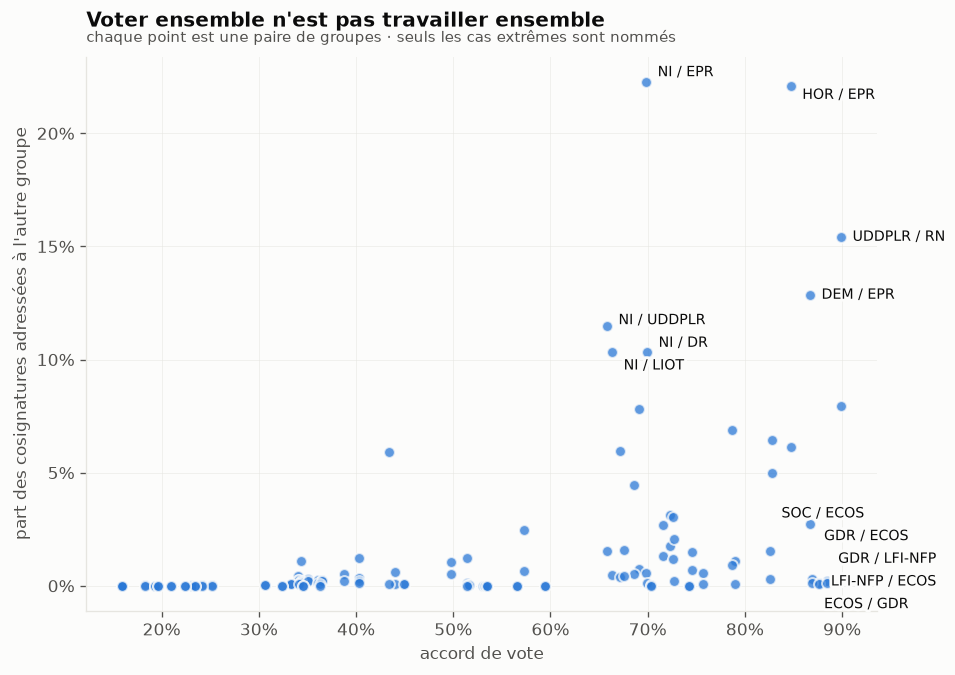

In [10]:
cube = analyze.build_cube()
comparaison = cosign.comparer_vote_et_cosignature(
    reseau, analyze.accord_entre_groupes(cube)
)
viz.nuage_vote_vs_cosignature(comparaison)
plt.show()

In [11]:
# Les paires qui votent beaucoup ensemble... sans jamais rien cosigner.
(comparaison.sort("accord_vote", descending=True)
            .filter(pl.col("part_cosignatures") < 0.01)
            .head(8)
            .select("groupe_a", "groupe_b", "accord_vote", "part_cosignatures", "liens"))

groupe_a,groupe_b,accord_vote,part_cosignatures,liens
str,str,f64,f64,f64
"""GDR""","""LFI-NFP""",0.884012,0.002237,51.0
"""LFI-NFP""","""GDR""",0.884012,0.001057,51.0
"""LFI-NFP""","""ECOS""",0.876549,0.001223,59.0
"""ECOS""","""LFI-NFP""",0.876549,0.000966,59.0
"""ECOS""","""GDR""",0.869474,0.001065,65.0
"""GDR""","""ECOS""",0.869474,0.002851,65.0
"""SOC""","""ECOS""",0.825682,0.003027,936.0
"""SOC""","""GDR""",0.789608,0.000815,252.0


Le contraste le plus net de tout ce travail :

- **LFI↔ECOS et LFI↔GDR votent ensemble à 88 %** et échangent environ **0,1 %**
  de leurs cosignatures. Le Nouveau Front populaire est une coalition de vote,
  pas un atelier législatif commun.
- **DR↔UDDPLR votent ensemble à 74 % avec zéro amendement cosigné.** Pas « peu » :
  aucun. Deux groupes de droite qui votent de concert les trois quarts du temps
  sans jamais avoir corédigé une ligne.

Aucune de ces deux observations n'est accessible depuis les votes. C'est ce que
la cosignature apporte.

## 8. Limites

- **Cosigner n'est pas rédiger.** Un député peut apposer son nom sans avoir
  participé au travail. Le réseau mesure une association publique revendiquée,
  ce qui reste plus engageant qu'un vote, mais moins qu'une corédaction.
- **Le plafond de 10 signataires est un choix**, montré sensible en section 3.
  Toute publication doit le mentionner.
- **Les amendements irrecevables comptent comme les autres.** Un amendement
  retoqué au titre de l'article 40 a été déposé et cosigné : l'intention est
  là, l'effet législatif non.
- **Les non-inscrits sont exclus des courtiers** : n'étant pas un groupe, leur
  « hors groupe » n'a pas de sens.

En ligne de commande :

```bash
uv run radar cosignatures --par-groupe
uv run radar courtiers
```